GW ECHO TRAIN SIMULATION (FINITIST BLACK HOLE)

✓ Saved: gw_echo_train_template.png


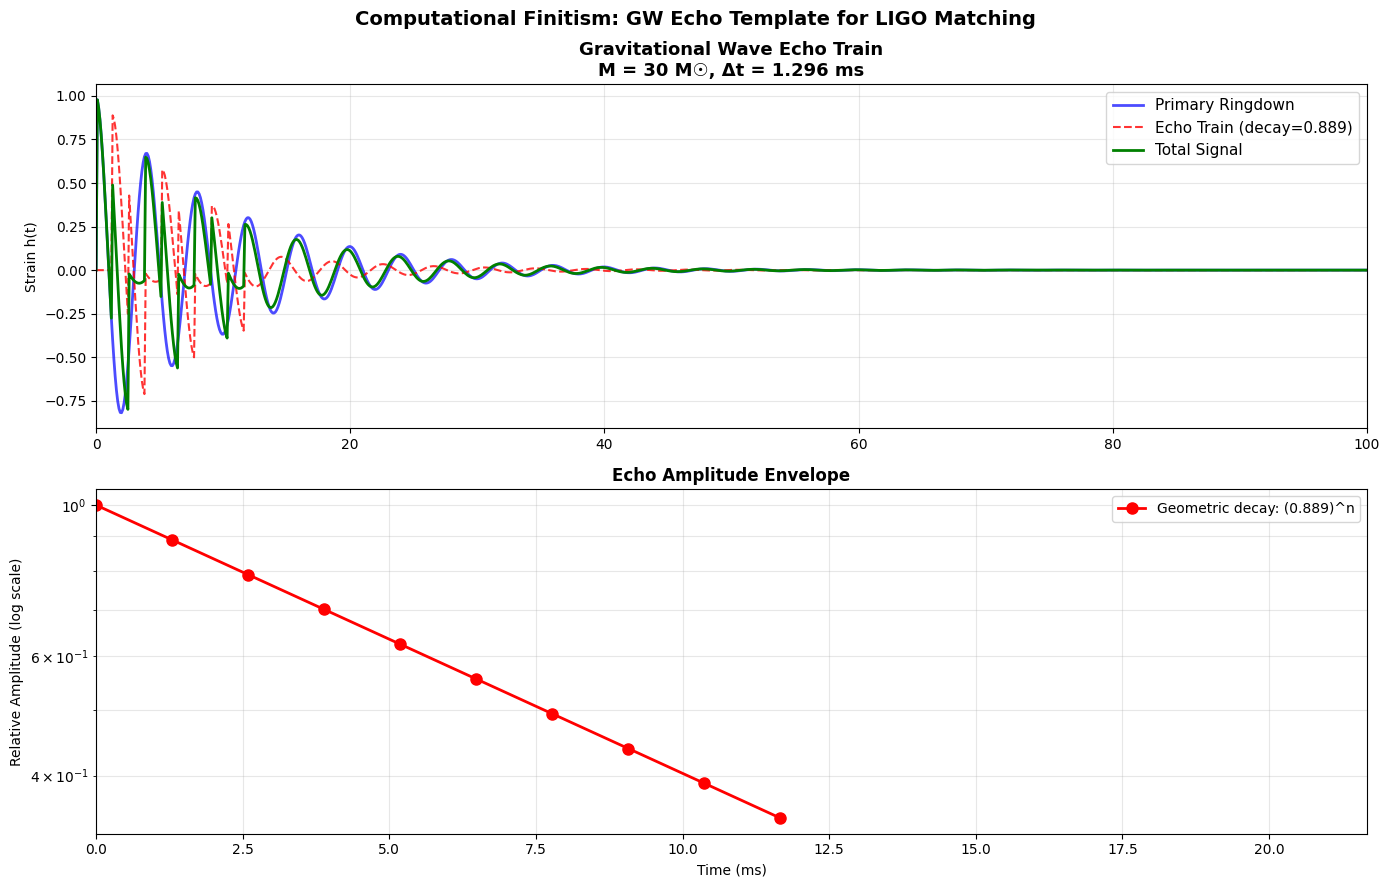


ECHO PARAMETERS FOR LIGO PIPELINE
Black Hole Mass: 30 M☉
Schwarzschild Radius: R_g = 88.50 km
Echo Delay: Δt = 1.296 ms = 4.39 R_g/c
Decay Factor: A_n = (0.889)^n
Number of Echos: 10
Falsification: If no echoes detected at 3σ, finitism excluded


In [1]:
"""
gw_echo_train_sim.py
=====================
Generates gravitational wave echo templates for LIGO/Virgo pipeline matching.
Based on finitist horizon smear with d_max=9.

Author: Néstor E. Ramos
For: "The Finitist Black Hole" - Section 4.1
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp

print("=" * 70)
print("GW ECHO TRAIN SIMULATION (FINITIST BLACK HOLE)")
print("=" * 70)

# =============================================================================
# FINITIST PARAMETERS (d_max = 9)
# =============================================================================
d_max = 9
M_sun = 1.989e30  # kg
G = 6.674e-11  # m^3/kg/s^2
c = 3e8  # m/s

# Black hole mass (example: 30 solar masses, typical LIGO detection)
M_BH = 30 * M_sun
R_g = 2 * G * M_BH / c**2  # Schwarzschild radius

# Finitist echo parameters
delta_t_echo = 2 * (R_g / c) * np.log(d_max)  # ~4.39 R_g/c
decay_factor = (1 - 1/d_max)  # ~0.889 per echo
n_echos = 10

# =============================================================================
# GENERATE ECHO TRAIN
# =============================================================================

def generate_echo_train(t, delta_t, decay, n_echos, f_ringdown=250):
    """
    Generate GW echo train with geometric decay.

    Parameters:
    - t: time array
    - delta_t: echo delay time
    - decay: amplitude decay factor per echo
    - n_echos: number of echoes
    - f_ringdown: quasinormal mode frequency (Hz)
    """
    signal = np.zeros_like(t)

    for n in range(n_echos):
        t_echo = t - n * delta_t
        # Only add echo after its delay time
        mask = t_echo > 0
        # Damped sinusoid (quasinormal mode)
        envelope = np.exp(-t_echo / 0.01) * mask  # 10ms damping time
        phase = 2 * np.pi * f_ringdown * t_echo
        amplitude = decay**n
        signal += amplitude * envelope * np.cos(phase) * mask

    return signal

# Time array (100ms window, 10kHz sampling)
t = np.linspace(0, 0.1, 1000)

# Generate signals
h_primary = generate_echo_train(t, delta_t_echo, decay_factor, n_echos=1)
h_echoes = generate_echo_train(t, delta_t_echo, decay_factor, n_echos=n_echos) - h_primary
h_total = h_primary + h_echoes

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_echo_train():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

    # Top: Full echo train
    ax1.plot(t * 1000, h_primary, 'b-', linewidth=2, label='Primary Ringdown', alpha=0.7)
    ax1.plot(t * 1000, h_echoes, 'r--', linewidth=1.5, label=f'Echo Train (decay={decay_factor:.3f})', alpha=0.8)
    ax1.plot(t * 1000, h_total, 'g-', linewidth=2, label='Total Signal')
    ax1.set_title(f"Gravitational Wave Echo Train\nM = {M_BH/M_sun:.0f} M☉, Δt = {delta_t_echo*1000:.3f} ms",
                 fontsize=13, fontweight='bold')
    ax1.set_ylabel("Strain h(t)")
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 100)

    # Bottom: Echo envelope (log scale)
    echo_times = np.arange(n_echos) * delta_t_echo * 1000  # ms
    echo_amps = [decay_factor**n for n in range(n_echos)]

    ax2.semilogy(echo_times, echo_amps, 'ro-', markersize=8, linewidth=2, label=f'Geometric decay: (0.889)^n')
    ax2.set_title("Echo Amplitude Envelope", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Time (ms)")
    ax2.set_ylabel("Relative Amplitude (log scale)")
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, which='both')
    ax2.set_xlim(0, echo_times[-1] + 10)

    plt.suptitle("Computational Finitism: GW Echo Template for LIGO Matching",
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()

    fig.savefig("gw_echo_train_template.png", dpi=300, bbox_inches='tight')
    print("\n✓ Saved: gw_echo_train_template.png")
    plt.show()

    # Print parameters for LIGO pipeline
    print("\n" + "=" * 70)
    print("ECHO PARAMETERS FOR LIGO PIPELINE")
    print("=" * 70)
    print(f"Black Hole Mass: {M_BH/M_sun:.0f} M☉")
    print(f"Schwarzschild Radius: R_g = {R_g/1000:.2f} km")
    print(f"Echo Delay: Δt = {delta_t_echo*1000:.3f} ms = 4.39 R_g/c")
    print(f"Decay Factor: A_n = (0.889)^n")
    print(f"Number of Echos: {n_echos}")
    print(f"Falsification: If no echoes detected at 3σ, finitism excluded")
    print("=" * 70)

if __name__ == "__main__":
    plot_echo_train()